In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid')

%matplotlib inline

In [2]:
# Load all processed files
processed_path = Path('../data/processed')
files = sorted(processed_path.glob('*.parquet'))

# Load and combine
df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)

print(f"Total records: {len(df):,}")
print(f"Date range: {df['FlightDate'].min()} to {df['FlightDate'].max()}")
print(f"Columns: {df.shape[1]}")

Total records: 38,761,873
Date range: 2019-01-01 00:00:00 to 2024-12-31 00:00:00
Columns: 38


In [3]:
# Basic info
print("=== DATASET OVERVIEW ===")
print(f"\nShape: {df.shape}")
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"\nData types:\n{df.dtypes}")

=== DATASET OVERVIEW ===

Shape: (38761873, 38)

Missing values:
Flight_Number_Reporting_Airline           1
Tail_Number                          258377
DepTime                              864975
ArrTime                              894329
CancellationCode                   37877310
CRSElapsedTime                          147
ActualElapsedTime                    975185
AirTime                              975185
dtype: int64

Data types:
Year                                        int64
Quarter                                     int64
Month                                       int64
DayofMonth                                  int64
DayOfWeek                                   int64
FlightDate                         datetime64[us]
Reporting_Airline                             str
Flight_Number_Reporting_Airline           float64
Tail_Number                                   str
Origin                                        str
OriginCityName                                str
OriginS

In [5]:
# On-time performance by year
yearly = df.groupby('Year').agg(
    total_flights=('ArrDel15', 'count'),
    delayed_flights=('ArrDel15', 'sum'),
    avg_arr_delay=('ArrDelay', 'mean'),
    cancelled=('Cancelled', 'sum')
).reset_index()

yearly['delay_rate'] = (yearly['delayed_flights'] / yearly['total_flights'] * 100).round(2)
yearly['cancel_rate'] = (yearly['cancelled'] / yearly['total_flights'] * 100).round(2)

print(yearly)

   Year  total_flights  delayed_flights  avg_arr_delay  cancelled  delay_rate  \
0  2019        7422037          1389253           5.30     134925       18.72   
1  2020        4688354           431921          -4.68     281034        9.21   
2  2021        5995397          1010332           3.03     103060       16.85   
3  2022        6729125          1376798           6.83     181286       20.46   
4  2023        6847899          1386699           6.53      87943       20.25   
5  2024        7079061          1449966           6.98      96315       20.48   

   cancel_rate  
0         1.82  
1         5.99  
2         1.72  
3         2.69  
4         1.28  
5         1.36  


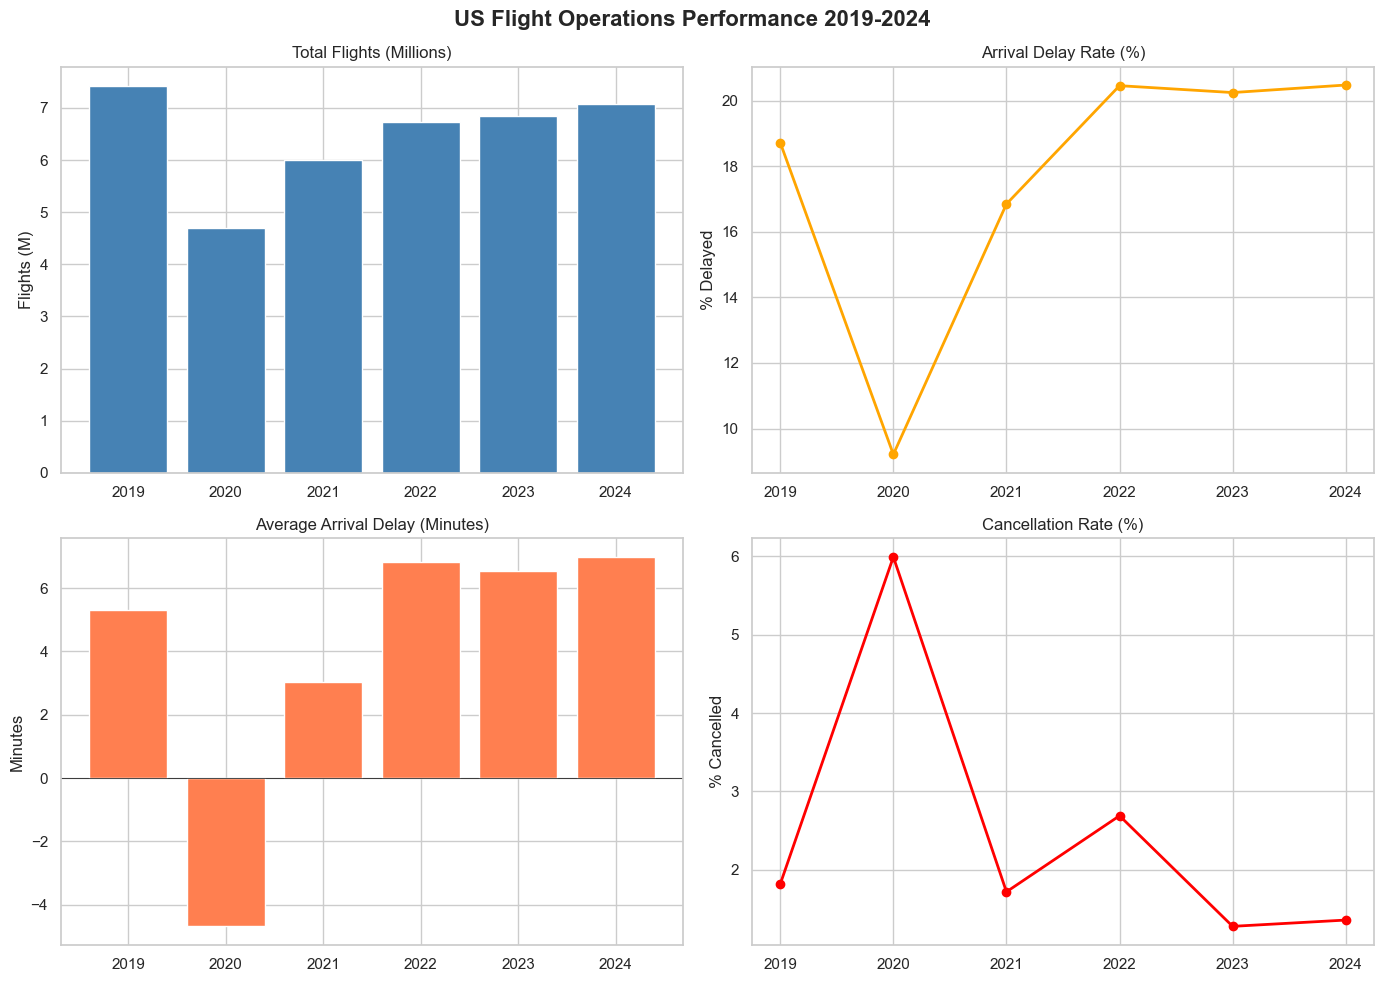

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('US Flight Operations Performance 2019-2024', fontsize=16, fontweight='bold')

# Total flights
axes[0,0].bar(yearly['Year'], yearly['total_flights']/1e6, color='steelblue')
axes[0,0].set_title('Total Flights (Millions)')
axes[0,0].set_ylabel('Flights (M)')

# Delay rate
axes[0,1].plot(yearly['Year'], yearly['delay_rate'], marker='o', color='orange', linewidth=2)
axes[0,1].set_title('Arrival Delay Rate (%)')
axes[0,1].set_ylabel('% Delayed')

# Average delay
axes[1,0].bar(yearly['Year'], yearly['avg_arr_delay'], color='coral')
axes[1,0].set_title('Average Arrival Delay (Minutes)')
axes[1,0].set_ylabel('Minutes')
axes[1,0].axhline(y=0, color='black', linewidth=0.5)

# Cancellation rate
axes[1,1].plot(yearly['Year'], yearly['cancel_rate'], marker='o', color='red', linewidth=2)
axes[1,1].set_title('Cancellation Rate (%)')
axes[1,1].set_ylabel('% Cancelled')

plt.tight_layout()
plt.savefig('../reports/yearly_performance_overview.png', dpi=150, bbox_inches='tight')
plt.show()

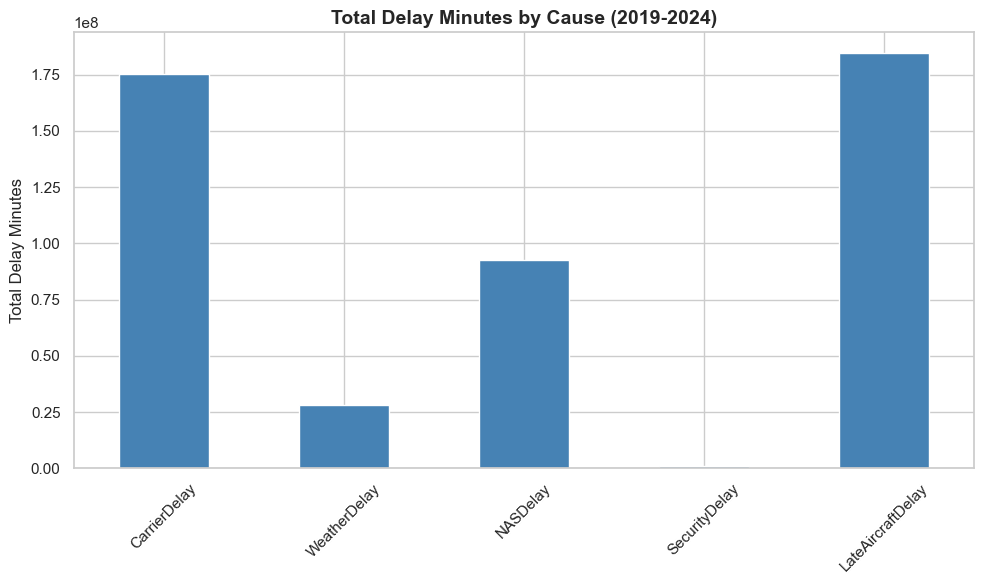


Delay cause breakdown (%):
CarrierDelay        36.41
WeatherDelay         5.84
NASDelay            19.21
SecurityDelay        0.21
LateAircraftDelay   38.33
dtype: float64


In [7]:
# Delay causes breakdown
delay_causes = df[['CarrierDelay', 'WeatherDelay', 'NASDelay', 
                    'SecurityDelay', 'LateAircraftDelay']].sum()

delay_causes.plot(kind='bar', figsize=(10, 6), color='steelblue')
plt.title('Total Delay Minutes by Cause (2019-2024)', fontsize=14, fontweight='bold')
plt.ylabel('Total Delay Minutes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/delay_causes.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nDelay cause breakdown (%):")
print((delay_causes / delay_causes.sum() * 100).round(2))